In [18]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

from phd.jax_core.tasks.feature_sifting import FeatureSiftingTaskNP as FeatureSiftingTask

In [19]:
SEED = 0
INPUT_DIM = 20

# V1: LMS

In [20]:
### Task init ###
task = FeatureSiftingTask(n_learner_features=INPUT_DIM, seed=SEED)
x, y = task.step(np.zeros(INPUT_DIM))

### Parameters ###
step_size = 0.01
train_steps = 5000
log_freq = 500

### Network init ###
weight_init_bound = np.sqrt(3/INPUT_DIM)
weights = np.random.uniform(-weight_init_bound, weight_init_bound, size=INPUT_DIM)

losses = []

for i in range(train_steps):
    
    ### Forward pass ###
    pred = x @ weights
    error = y - pred
    loss = error ** 2
    losses.append(loss)
    
    ### Backward pass ###
    grad = error * -x
    weights -= step_size * grad
    
    ### New sample ###
    x, y = task.step(np.zeros(INPUT_DIM))
    
    ### Logging ###
    if (i + 1) % log_freq == 0:
        print(f'Step {i + 1} loss: {np.mean(losses[-log_freq:])}')


Step 500 loss: 1.8810683982256953
Step 1000 loss: 1.261196776156483
Step 1500 loss: 1.1090443626692217
Step 2000 loss: 1.1949730738366704
Step 2500 loss: 1.1990002738611636
Step 3000 loss: 1.1485890350380916
Step 3500 loss: 1.2734770335150083
Step 4000 loss: 1.2293336432650146
Step 4500 loss: 1.2638097582911454
Step 5000 loss: 1.1524077826487666


# V2: Utility-Based Pruning


The problem with this algorithm is that we don't want to prune at a fixed rate. How likely we are to prune something should depend on factors like how good the generator is and how noisy the problem is.

Step 500 loss: 2.2844861799305054
Step 1000 loss: 1.0822924667904545
Step 1500 loss: 0.7297143879500491
Step 2000 loss: 0.7382839352577506
Step 2500 loss: 0.5206719343080081
Step 3000 loss: 0.5021157678540767
Step 3500 loss: 0.3501618387225926
Step 4000 loss: 0.24163877464314004
Step 4500 loss: 0.2041809011465961
Step 5000 loss: 0.20469663035745778


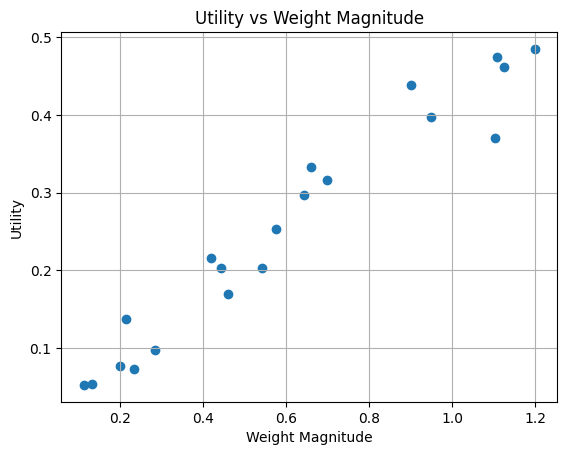

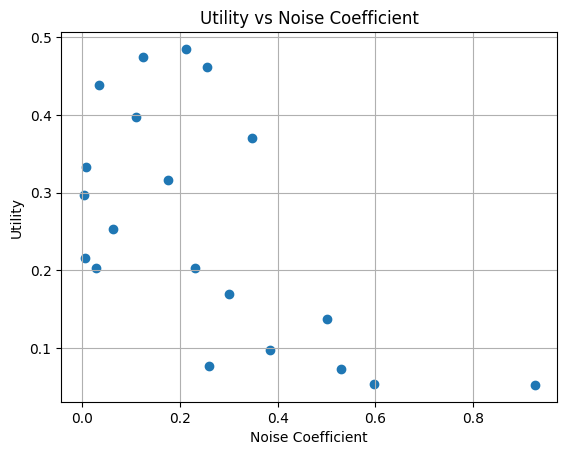

In [21]:
### Task init ###
task = FeatureSiftingTask(n_learner_features=INPUT_DIM, seed=SEED)
x, y = task.step(np.zeros(INPUT_DIM))

### Parameters ###
step_size = 0.01
train_steps = 5000
log_freq = 500
ema_decay = 0.98
prune_freq = int(2 / (1 - ema_decay))

### Network init ###
weight_init_bound = np.sqrt(3/INPUT_DIM)
weights = np.random.uniform(-weight_init_bound, weight_init_bound, size=INPUT_DIM)
utilities = np.zeros(INPUT_DIM)

losses = []

for i in range(train_steps):
    
    ### Forward pass ###
    pred = x @ weights
    error = y - pred
    loss = error ** 2
    losses.append(loss)
    
    ### Backward pass ###
    grad = error * -x
    weights -= step_size * grad
    
    ### Utility update ###
    step_utilities = np.abs(x * weights)
    utilities = ema_decay * utilities + (1 - ema_decay) * step_utilities
    
    ### Pruning ###
    prune_mask = np.zeros(INPUT_DIM)
    if (i + 1) % prune_freq == 0:
        lowest_idx = np.argmin(utilities)
        utilities[lowest_idx] = np.median(utilities)
        weights[lowest_idx] = np.random.uniform(-weight_init_bound, weight_init_bound)
        prune_mask[lowest_idx] = 1
    
    ### New sample ###
    x, y = task.step(prune_mask)
    
    ### Logging ###
    if (i + 1) % log_freq == 0:
        print(f'Step {i + 1} loss: {np.mean(losses[-log_freq:])}')

plt.scatter(np.abs(weights), utilities)
plt.xlabel('Weight Magnitude')
plt.ylabel('Utility')
plt.title('Utility vs Weight Magnitude')
plt.grid(True)
plt.show()

plt.scatter(task.noise_coefficients, utilities)
plt.xlabel('Noise Coefficient')
plt.ylabel('Utility')
plt.title('Utility vs Noise Coefficient')
plt.grid(True)
plt.show()



# Can we predict the outcome of pruning?

In [22]:
# 1. Create a loop for the same feature sifting task we've been using
# 2. Every 5,000 steps:
#     a. Select a random index to prune
#     b. Create 200 variants of the current task, just with different seeds
#     c. Prune the index in half of the variants
#     d. Simulate all variants for 10,000 steps using the same train loop, but without pruning
#     e. Record the loss to compute the statistics mentioned below

# What is the purpose of this?
# - I want to compute a ground truth for how likely pruning is to be good, and whether it is a good decision in expectation.
# - I want to test whether this decision aligns with whether the feature would improve performance in theory (does it increase the net signal available?)
# - I want to see what the threshold horizon is for when pruning becomes the right decision.

# The first and second of these points aren't too hard to compute, but the second may be too tough for now.
# The first one we can do looking at the cumulative loss difference across the envs with and without pruning.
# If the cumulative loss is lower with pruning, then we can say that pruning is good.
# We can bootstrap by pulling random pairs of samples from prune and no prune envs to estiamte the probability that pruning is good.

# For the third we can look again at the cumulative loss difference, but look at it at each point in time.
# If the difference is positive at some point, then we can say that pruning is good at that point.
# And we can again do the same thing where we compute the probability that the difference is positive at any point.

# Do display these stats, I want to create a ploit for each pruning event (10 events) throughout training.
# Each plot should plot the loss difference and probability of good prune across time, in the same plot with 2 y-axes labels.
# They should also include the numbers for the cumulative loss difference and probability of good prune at the end of the 10k horizon.

# To do this efficiently, I'll need to switch back to using JAX and scan the train loop + vmap the variant creation and simulation.
# I can go back to the JAX version of the task I was using before.


## Ground truth: would pruning a random feature help?

We train one continuous **no-prune reference trajectory** with LMS. Every `PRUNE_FREQ` (5,000) steps we
take a checkpoint of the task + learner and branch off `N_PAIRS` (200) **matched pairs** of worlds. Both
members of a pair share a seed (**common random numbers**), so the task feeds them the same target stream
and the same feature noise every step — they differ *only* in the one feature we prune in one member (it
regenerates that task feature + zeroes its learner weight). Both run forward `SIM_STEPS` (10,000) steps
with no further pruning. Pairing differences out the sample-stream luck, isolating the causal effect of
the prune; the reference trajectory itself is never modified.

For each of the 10 events, per pair `i` we track `D_i(t) = (no-prune cum. loss) − (prune cum. loss)`:

- **Avg per-step loss difference** `= D_i(t) / steps` (blue) — positive means pruning helped. Plotted as a
  running average so it converges to a steady-state *rate* instead of growing without bound; its
  zero-crossing (same sign as the cumulative) is the **threshold horizon** at which pruning starts to pay
  off. Faint lines = individual pairs; the bold line = the mean (the in-expectation answer).
- **P(good prune)** (red) — the fraction of pairs above zero, i.e. how often pruning is the better call.
  It is exactly the share of faint blue lines currently positive, so a positive mean with red `< 1` means
  the winning pairs simply outweigh the losing ones (a right-skewed outcome distribution).

Everything runs in JAX: the train loop is a `lax.scan`, and pair creation + simulation are `vmap`ped.

In [23]:
# === Ground-truth setup: JAX task + a scannable / vmappable LMS train loop ===
from functools import partial

import jax
import jax.numpy as jnp

from phd.jax_core.tasks.feature_sifting import FeatureSiftingTask as FeatureSiftingTaskJAX
from phd.jax_core.utils import tree_replace

# --- Experiment configuration ---
N_TARGET_FEATURES = 10      # matches the task default used throughout this notebook
STEP_SIZE = 0.01            # LMS step size (same train loop as the cells above)
MAIN_STEPS = 50_000         # length of the reference (no-prune) training trajectory
PRUNE_FREQ = 5_000          # run a prune-outcome experiment every this many steps
N_EVENTS = MAIN_STEPS // PRUNE_FREQ   # -> 10 pruning events
SIM_STEPS = 10_000          # horizon each variant is simulated for after the (non-)prune
N_PAIRS = 200               # matched prune/no-prune pairs per event (common random numbers)

WEIGHT_INIT_BOUND = float(jnp.sqrt(3 / INPUT_DIM))


def lms_step(weights, x, y, step_size):
    """One LMS update on a single (x, y) sample; returns (new_weights, squared_error)."""
    pred = x @ weights
    error = y - pred
    loss = error ** 2
    grad = error * -x
    return weights - step_size * grad, loss


def train_step(task, weights, prune_mask, step_size):
    """Draw one sample (regenerating any masked feature) and take one LMS step."""
    task, (x, y) = task.step(prune_mask)
    weights, loss = lms_step(weights, x, jnp.squeeze(y), step_size)
    return task, weights, loss


@partial(jax.jit, static_argnames=('n_steps',))
def run_segment(task, weights, step_size, n_steps):
    """Advance the reference trajectory `n_steps` steps with no pruning (scanned + jitted)."""
    no_prune = jnp.zeros(task.n_learner_features, dtype=bool)

    def body(carry, _):
        task, weights = carry
        task, weights, loss = train_step(task, weights, no_prune, step_size)
        return (task, weights), loss

    (task, weights), losses = jax.lax.scan(body, (task, weights), length=n_steps)
    return task, weights, losses


def simulate_variant(key, base_task, weights, prune_index, do_prune, step_size, n_steps):
    """Simulate one task variant for `n_steps` with no pruning, optionally pruning `prune_index`
    on the very first step (which regenerates that task feature and zeroes its learner weight).
    Returns the per-step squared-error losses, shape (n_steps,)."""
    n = base_task.n_learner_features
    task = tree_replace(base_task, rng=key)                       # same task config, fresh RNG
    weights = weights.at[prune_index].set(jnp.where(do_prune, 0.0, weights[prune_index]))
    init_mask = jnp.zeros(n, dtype=bool).at[prune_index].set(do_prune)
    no_prune = jnp.zeros(n, dtype=bool)

    task, weights, loss0 = train_step(task, weights, init_mask, step_size)  # the (non-)prune step

    def body(carry, _):
        task, weights = carry
        task, weights, loss = train_step(task, weights, no_prune, step_size)
        return (task, weights), loss

    (task, weights), losses = jax.lax.scan(body, (task, weights), length=n_steps - 1)
    return jnp.concatenate([loss0[None], losses])


@partial(jax.jit, static_argnames=('n_steps', 'n_pairs'))
def run_simulation(key, base_task, weights, prune_index, step_size, n_steps, n_pairs):
    """Build `n_pairs` MATCHED pairs of variants (common random numbers). Both members of a pair
    share a seed, so the task hands them the same target stream and the same feature noise every
    step; after the first step they even carry the identical RNG. They therefore differ ONLY by
    the single regenerated feature at `prune_index` (and the learner divergence it causes) -- the
    clean causal contrast of pruning, with the sample-stream luck differenced out. Returns
    (prune_losses, noprune_losses), each of shape (n_pairs, n_steps), aligned row-by-row."""
    keys = jax.random.split(key, n_pairs)

    def sim_pair(k):
        prune = simulate_variant(k, base_task, weights, prune_index, True, step_size, n_steps)
        noprune = simulate_variant(k, base_task, weights, prune_index, False, step_size, n_steps)
        return prune, noprune

    return jax.vmap(sim_pair)(keys)

In [24]:
# === Run the reference trajectory and a prune-outcome experiment at every checkpoint ===
# The reference trajectory trains continuously WITHOUT pruning. Every PRUNE_FREQ steps we branch
# off N_PAIRS matched pairs of the current task (each pair shares a seed; one member prunes a
# random feature, the other does not) and roll all of them forward SIM_STEPS steps to see how the
# prune would have played out. The reference trajectory itself is never modified.
key = jax.random.PRNGKey(SEED)
task_key, init_key, loop_key = jax.random.split(key, 3)

task = FeatureSiftingTaskJAX(
    n_target_features=N_TARGET_FEATURES, n_learner_features=INPUT_DIM, key=task_key)
weights = jax.random.uniform(
    init_key, (INPUT_DIM,), minval=-WEIGHT_INIT_BOUND, maxval=WEIGHT_INIT_BOUND)

event_results = []
for event in range(N_EVENTS):
    # Advance the reference (no-prune) trajectory to the next checkpoint.
    task, weights, _ = run_segment(task, weights, STEP_SIZE, PRUNE_FREQ)
    step = (event + 1) * PRUNE_FREQ

    # a. Pick a random feature index to (counterfactually) prune; note its noise coefficient
    #    (0 = clean view of a target feature, 1 = pure noise -> the higher, the more useless).
    loop_key, idx_key, sim_key = jax.random.split(loop_key, 3)
    prune_index = jax.random.randint(idx_key, (), 0, INPUT_DIM)
    prune_noise_coef = float(task.noise_coefficients[prune_index])

    # b-e. Simulate N_PAIRS matched (prune, no-prune) worlds for SIM_STEPS, record per-step losses.
    prune_losses, noprune_losses = run_simulation(
        sim_key, task, weights, prune_index, STEP_SIZE, SIM_STEPS, N_PAIRS)
    event_results.append({
        'step': step,
        'prune_index': int(prune_index),
        'noise_coef': prune_noise_coef,
        'prune_losses': np.asarray(prune_losses),       # (N_PAIRS, SIM_STEPS)
        'noprune_losses': np.asarray(noprune_losses),   # (N_PAIRS, SIM_STEPS), paired row-by-row
    })
    print(f'Event {event + 1}/{N_EVENTS} @ step {step}: pruned feature {int(prune_index)} '
          f'(noise coef {prune_noise_coef:.2f}), simulated {N_PAIRS} matched pairs x {SIM_STEPS} steps')

Event 1/10 @ step 5000: pruned feature 2 (noise coef 0.97), simulated 200 matched pairs x 10000 steps
Event 2/10 @ step 10000: pruned feature 9 (noise coef 0.65), simulated 200 matched pairs x 10000 steps
Event 3/10 @ step 15000: pruned feature 14 (noise coef 0.63), simulated 200 matched pairs x 10000 steps
Event 4/10 @ step 20000: pruned feature 14 (noise coef 0.63), simulated 200 matched pairs x 10000 steps
Event 5/10 @ step 25000: pruned feature 10 (noise coef 0.10), simulated 200 matched pairs x 10000 steps
Event 6/10 @ step 30000: pruned feature 18 (noise coef 0.46), simulated 200 matched pairs x 10000 steps
Event 7/10 @ step 35000: pruned feature 8 (noise coef 0.63), simulated 200 matched pairs x 10000 steps
Event 8/10 @ step 40000: pruned feature 12 (noise coef 0.02), simulated 200 matched pairs x 10000 steps
Event 9/10 @ step 45000: pruned feature 18 (noise coef 0.46), simulated 200 matched pairs x 10000 steps
Event 10/10 @ step 50000: pruned feature 5 (noise coef 0.99), simula

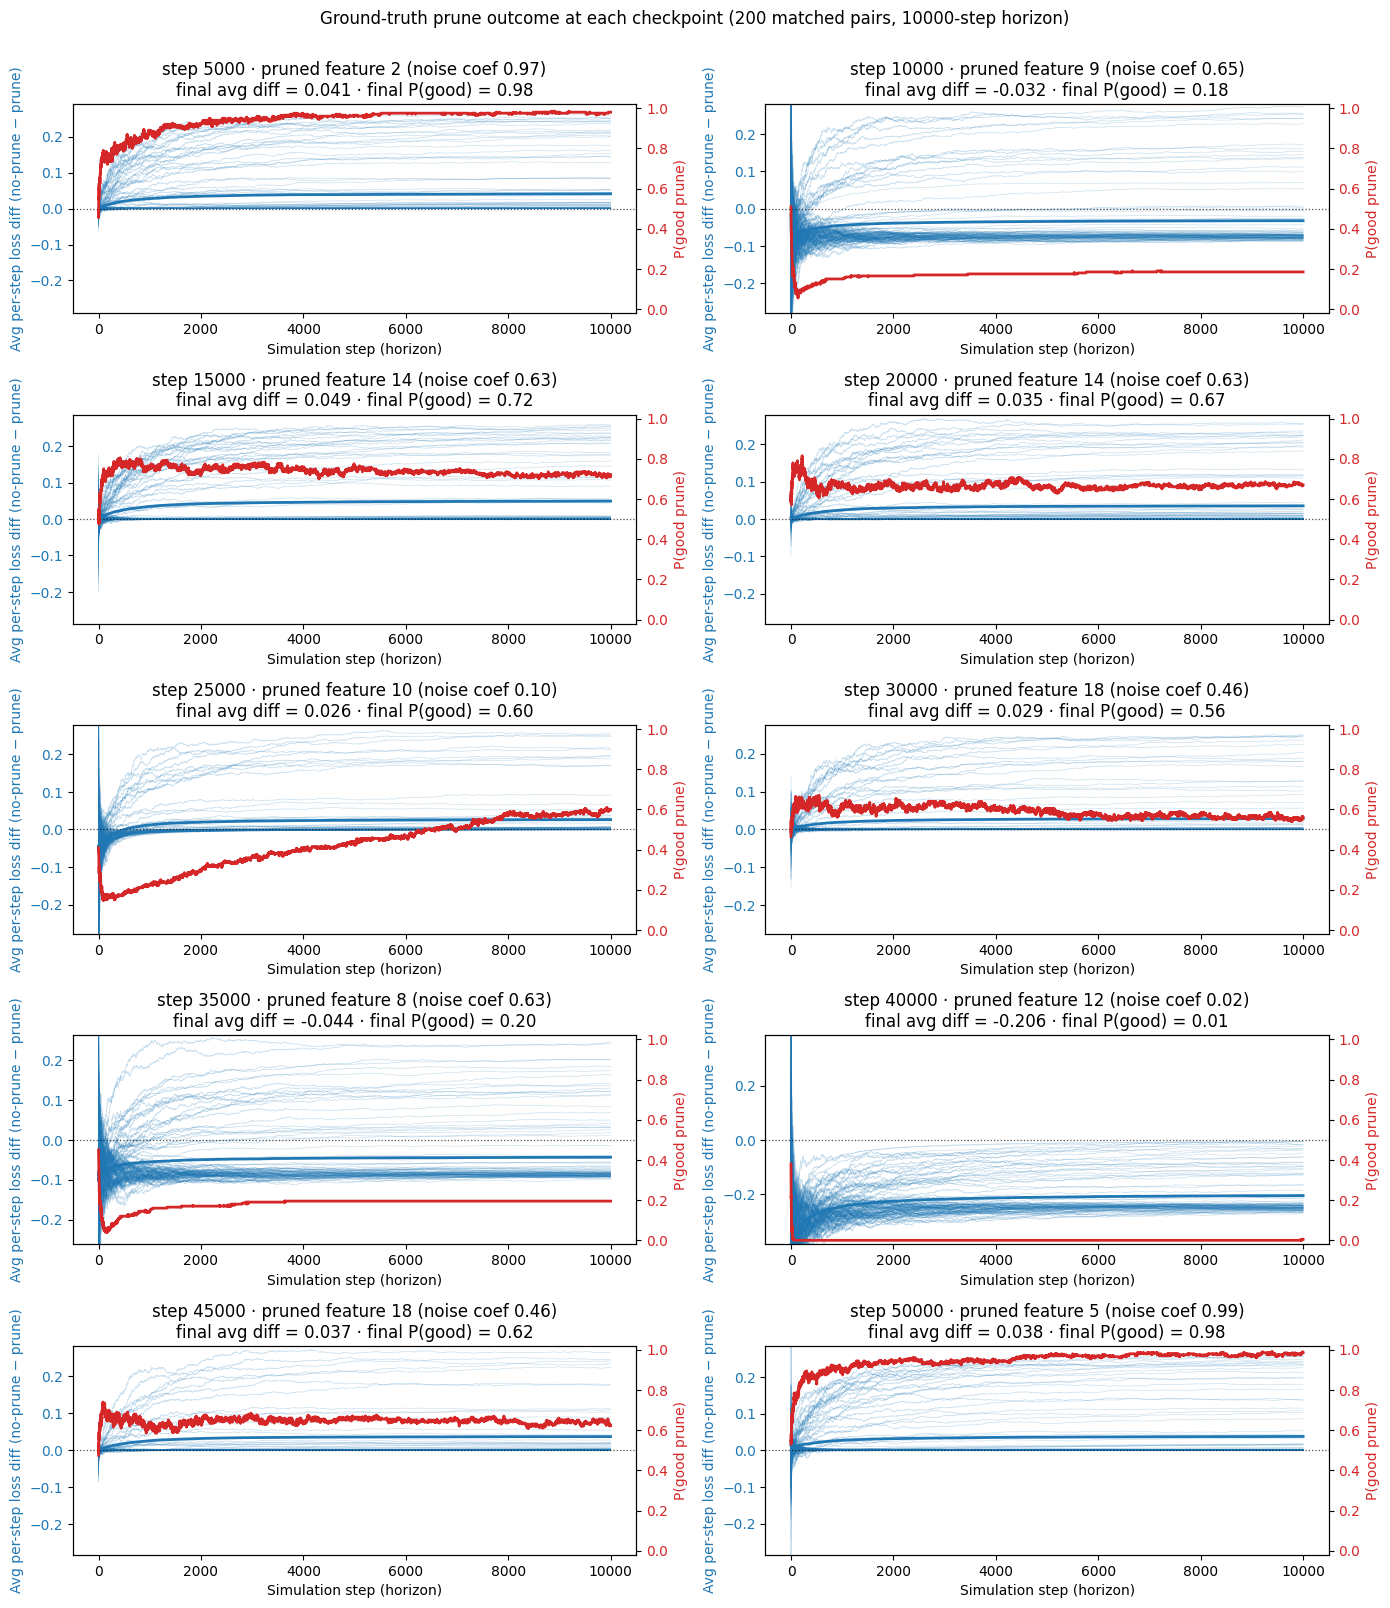

In [25]:
# === Statistics + per-event plots (matched pairs / common random numbers) ===
# Per matched pair i: D_i(t) = (no-prune cum. loss) - (prune cum. loss) up to step t; > 0 means
# pruning won that pair. We plot D_i(t) as a *running per-step average* (D_i(t) / steps_so_far) so
# the curves flatten to a steady-state advantage RATE instead of growing without bound -- but the
# zero-crossing is unchanged (same sign as the cumulative), so the threshold horizon is preserved.
#
#   * faint blue lines = a random subset of individual pairs (the spread of outcomes)
#   * solid blue line  = the mean over ALL pairs (the in-expectation answer)
#   * red line         = fraction of pairs above zero = P(pruning is the better call). This is
#                        literally "what fraction of the faint blue lines are currently positive",
#                        so a mean that is positive while red < 1 means the winners simply outweigh
#                        the losers (a right-skewed outcome distribution).
# Each title also lists the pruned feature's noise coefficient (0 = clean, 1 = pure noise): a high
# coefficient is a useless feature that should be cheap-to-good to prune; a low one is informative.
# The left y-axis is centered on 0 so the sign of the average advantage is read off the midline.
N_SHOWN_PAIRS = 100   # number of faint per-pair lines drawn per event


def compute_event_stats(res):
    cum_prune = np.cumsum(res['prune_losses'], axis=1)
    cum_noprune = np.cumsum(res['noprune_losses'], axis=1)
    steps = np.arange(1, cum_prune.shape[1] + 1)          # steps elapsed so far
    pair_diff = (cum_noprune - cum_prune) / steps         # per-pair running avg diff; > 0 -> prune better
    mean_diff = pair_diff.mean(0)                         # mean over all pairs (in-expectation)
    prob_good = (cum_noprune > cum_prune).mean(0)         # fraction of pairs where pruning won
    return pair_diff, mean_diff, prob_good


n_cols = 2
n_rows = int(np.ceil(N_EVENTS / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 3.2 * n_rows))
axes = np.atleast_1d(axes).ravel()
t = np.arange(SIM_STEPS)
rng = np.random.default_rng(0)
warmup = max(50, SIM_STEPS // 50)   # ignore the first-step transient when auto-scaling the y-axis

for ax, res in zip(axes, event_results):
    pair_diff, mean_diff, prob_good = compute_event_stats(res)

    # Faint per-pair lines: each is one matched pair's running-average loss difference.
    shown = rng.choice(pair_diff.shape[0], size=min(N_SHOWN_PAIRS, pair_diff.shape[0]), replace=False)
    ax.plot(t, pair_diff[shown].T, color='tab:blue', lw=0.5, alpha=0.22)

    ax.axhline(0.0, color='black', lw=0.9, ls=':', alpha=0.4)
    ax.plot(t, mean_diff, color='tab:blue', lw=2.0)      # mean over all pairs
    ax.set_xlabel('Simulation step (horizon)')
    ax.set_ylabel('Avg per-step loss diff (no-prune − prune)', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    # Symmetric y-limits so 0 sits in the middle; scaled by the faint lines after the transient.
    lo, hi = np.percentile(pair_diff[:, warmup:], [1, 99])
    ymax = 1.15 * max(abs(lo), abs(hi), 1e-12)
    ax.set_ylim(-ymax, ymax)

    ax2 = ax.twinx()
    ax2.axhline(0.5, color='black', lw=0.9, ls=':', alpha=0.4)
    ax2.plot(t, prob_good, color='tab:red', lw=2.0)
    ax2.set_ylabel('P(good prune)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.set_ylim(-0.02, 1.02)

    ax.set_title(f"step {res['step']} · pruned feature {res['prune_index']} "
                 f"(noise coef {res['noise_coef']:.2f})\n"
                 f"final avg diff = {mean_diff[-1]:.3f} · final P(good) = {prob_good[-1]:.2f}")

# Hide any unused axes (when N_EVENTS doesn't fill the grid).
for ax in axes[len(event_results):]:
    ax.set_visible(False)

fig.suptitle('Ground-truth prune outcome at each checkpoint '
             f'({N_PAIRS} matched pairs, {SIM_STEPS}-step horizon)', y=1.002)
fig.tight_layout()
plt.show()

In [26]:
# Now I can compare these things to the estimates I have of them
# First I can look at the utility of the existing feature, that's the easy one
# Then I can look at the utility of the new feature
# I can compute standard error of the mean of both and use that to get a probability of it being good, or what I reall want, the expected change in average utility

In [27]:
# The next step is to try some methods to estimate the convergent utility bounds of new features.
# To be clear, the goal is not to get the utility of the feature at a given time, but to estimate the bounds of what the utility of the feature will eventually be.
# This is a little different from what I was plotting in the previous plots, as that was the difference between prune and no-prune utilities over time.
# For this step I am purely focused on the utility of a new feature after a pruning has been done and where it will converge to.

# The way I will do this is prune one feature every 5k steps at random, then measure the utility of the feature at each step (ema of absolute value of weight times feature input).
# For those 5k steps, I will also estimate 95% confidence intervals for the convergent utility of the feature using multiple different methods, logging the estimates of each.
# I will run run this for 500k steps to collect data on 100 samples, then report the results, plotting a few things:
#   - Utility curves over learning and their confidence intervals for each different method, 4 examples per method.
#   - One plot per method that averages over all samples. There should be 2 lines, one for the upper confidence bound and one for the lower.
#     The lines should be averages over all samples for how much greater/lower than the utility the predicted CI was.
#     These are essentially the average margins of the confidence intervals. Both of these lines should have their own 95% confidence intervals plotted.
#   - Not a plot, but a listing of each method, what percent of the time (what fraction of steps over all samples) was the utility less than the predicted CI lower bound.
#     What fraction of the time was it greater than the predicted CI upper bound. These should add up to ~5%

# To be clear, the thing you are plotting against and computing margins for is not the utility at each step, but the utility at the end of the 5k steps.
# The confidence intervals are compute at each step given only the current data and any historical statistics they use, but the whole point is that they
# are meant to predict what the potential utility is, not what the utility is at each step.

## V3.2: Estimating a feature's *convergent* utility (with confidence)

One continuous LMS run. Every `TRACK_STEPS` (5,000) steps we prune a **random** feature (regenerate
its task feature + zero its learner weight) and then follow that fresh feature for the whole window,
with no further pruning while the rest of the learner keeps training. Its **utility** is the debiased
EMA of `|w·x|` (decay `UTIL_ETA`). What we care about is not the utility *at each step* but where it
**converges** — operationalised as the utility at the **end** of the window. That end value is the
`target` each method's confidence interval is judged against. Over 500k steps this yields 100 tracked
features.

At every step, from only the data seen so far, each method emits a 95% CI meant to bracket that
convergent value. The key split is whether a method bounds the utility *as it is now* (and so must
wait for the weight to climb) or predicts where it is *headed* from the correlation structure:

- **Corr-ESS** — debiased-EMA mean/variance of the **current** utility `|w·x|`, with an effective
  sample size from the weight's tracking autocorrelation `r = (1-η)(1-ĝ)`,
  `ESS = (2-η)/η · (1-r)/(1+r)`. Because consecutive `|w·x|` are heavily autocorrelated (the weight
  drifts slowly) this discount makes the band wide — so it covers the target, but only by being loose.
- **Fable-EB** — the empirical-Bernstein interval from `fable_method.py`, used the way Fable intends:
  it bounds the **optimal** weight `w* = a/m` implied by the feature's correlation with the residual
  (`a = g + w·m`, `g = ema(e·x)`), *not* the current weight, so it predicts the convergent utility
  before `w` has climbed. `se = z·(√(V/n_eff) + 3√(e²·m)/n_eff)`, `n_eff = min(age, 2/λ)` is the
  standard error on that correlation; `[a±se]/m` bounds `|w*|`, and `×ema(|x|)` maps to the L1 utility.
- **Age-SEM** — simplest baseline: textbook standard-error-of-the-mean of the **current** utility with
  the raw sample count (`age`) as `n`. Assumes every step is independent → wildly overconfident.

Each method is a self-contained `eqx.Module` (`init()` + `step(x, w, e) -> (state, (lo, hi))`); add
new ones by appending to `CI_METHODS`. We then report **(1)** example utility curves + CIs, **(2)** the
average CI margin around the convergent value per method, and **(3)** the miss rates (fraction of
steps where the convergent utility fell below the lower / above the upper bound — ideally ≈2.5% each,
≈5% total).

In [59]:
# === V3.2 setup: methods for estimating a feature's CONVERGENT utility, + the windowed runner ===
import equinox as eqx

# --- experiment / measurement config ---
TRACK_STEPS  = 5_000                      # steps we follow each freshly pruned feature
TOTAL_STEPS  = 500_000                    # total continual-training steps -> 100 tracked features
N_SAMPLES    = TOTAL_STEPS // TRACK_STEPS
WARMUP_STEPS = 10_000                     # let the continual learner reach steady state first
UTIL_ETA = 0.01                           # EMA decay defining ground-truth utility = ema(|w*x|)
Z = 1.96                                  # 95% normal quantile
EPS = 1e-8
# (STEP_SIZE, INPUT_DIM, N_TARGET_FEATURES, WEIGHT_INIT_BOUND, SEED, lms_step, run_segment,
#  FeatureSiftingTaskJAX and tree_replace are all defined in the ground-truth cells above.)

# --- CI methods --------------------------------------------------------------------------------
# Each method is a self-contained eqx.Module with `init()` (fresh per-feature state) and
# `step(x, w, e) -> (new_state, (lo, hi))` returning a 95% CI for the feature's *convergent* utility,
# given this step's feature value x, current learner weight w, and global prediction residual e. Add
# a method by defining such a class and appending (name, cls) to CI_METHODS.


class CorrESS(eqx.Module):
    """Debiased-EMA mean/variance of the CURRENT utility y = |w*x|, with a correlation-based
    effective sample size. The weight tracks its target with residual autocorrelation
    r = (1-eta)(1-g_hat), so the effective sample size is discounted: ESS = (2-eta)/eta*(1-r)/(1+r),
    half = z*sqrt(V_hat/ESS). Bounds where the utility *is now*, so it must wait for w to climb."""
    alpha: float = eqx.field(static=True)
    eta: float = eqx.field(static=True)
    z: float = eqx.field(static=True)
    U: jax.Array
    V: jax.Array
    gbar: jax.Array
    b: jax.Array

    @classmethod
    def init(cls):
        return cls(alpha=STEP_SIZE, eta=UTIL_ETA, z=Z,
                   U=jnp.array(0.0), V=jnp.array(0.0), gbar=jnp.array(0.0), b=jnp.array(0.0))

    def step(self, x, w, e):
        eta = self.eta
        g = self.alpha * x * x
        y = jnp.abs(w * x)
        b = (1 - eta) * self.b + eta                  # cold-start debias factor = 1 - (1-eta)^t
        gbar = (1 - eta) * self.gbar + eta * g
        dev = y - self.U
        U = (1 - eta) * self.U + eta * y
        V = (1 - eta) * self.V + eta * dev * dev
        U_hat = U / b
        V_hat = V / b
        g_hat = jnp.minimum(gbar / b, 1.0)
        r = (1 - eta) * (1 - g_hat)
        ess = jnp.maximum((2 - eta) / eta * (1 - r) / (1 + r), 1.0)
        half = self.z * jnp.sqrt(V_hat / ess)
        return tree_replace(self, U=U, V=V, gbar=gbar, b=b), (U_hat - half, U_hat + half)


class FableEB(eqx.Module):
    """Correlation-based empirical-Bernstein interval, adapted from fable_method.py.

    Fable does not bound the *current* weight's utility — it bounds the OPTIMAL weight implied by the
    feature's correlation with the residual error, so it can predict the convergent utility before the
    learner weight has climbed. Track g = ema(e*x) (the feature's correlation with the global residual)
    and m = ema(x*x); adding this feature's own contribution back gives the *self-excluded* correlation
    a = g + w*m, whose least-squares optimum is the convergent weight w* = a/m. Fable's empirical-
    Bernstein se = z*(sqrt(V/n_eff) + 3*sqrt(e2*m)/n_eff), n_eff = min(age, 2/lam), is the standard
    error on that correlation; pushing [a-se, a+se] through /m bounds |w*| (the ucb/lcb logic of Fable,
    here without the square), and multiplying by xbar = ema(|x|) maps to the L1 utility E|w* x|."""
    lam: float = eqx.field(static=True)
    z: float = eqx.field(static=True)
    eps: float = eqx.field(static=True)
    g: jax.Array       # EMA of e*x  (feature-residual correlation)
    m: jax.Array       # EMA of x*x
    q: jax.Array       # EMA of (e*x)^2
    e2: jax.Array      # EMA of e^2  (residual scale, for the EB range term)
    xbar: jax.Array    # EMA of |x|  (maps the optimal weight to L1 utility)
    b: jax.Array
    age: jax.Array

    @classmethod
    def init(cls):
        return cls(lam=1/5000, z=Z, eps=EPS, g=jnp.array(0.0), m=jnp.array(0.0), q=jnp.array(0.0),
                   e2=jnp.array(0.0), xbar=jnp.array(0.0), b=jnp.array(0.0), age=jnp.array(0.0))

    def step(self, x, w, e):
        lam = self.lam
        ex = e * x
        b = (1 - lam) * self.b + lam
        g = (1 - lam) * self.g + lam * ex
        m = (1 - lam) * self.m + lam * (x * x)
        q = (1 - lam) * self.q + lam * (ex * ex)
        e2 = (1 - lam) * self.e2 + lam * (e * e)
        xbar = (1 - lam) * self.xbar + lam * jnp.abs(x)
        age = self.age + 1.0
        g_hat, m_hat, q_hat = g / b, m / b, q / b
        e2_hat, xbar_hat = e2 / b, xbar / b
        a = g_hat + w * m_hat                              # self-excluded correlation -> w* = a/m_hat
        n_eff = jnp.minimum(age, 2.0 / lam)
        V = jnp.maximum(q_hat - g_hat * g_hat, 0.0) * n_eff / jnp.maximum(n_eff - 1.0, 1.0)
        se = self.z * (jnp.sqrt(V / n_eff) + 3.0 * jnp.sqrt(e2_hat * m_hat) / n_eff)  # SE on the corr.
        inv_m = 1.0 / (m_hat + self.eps)
        lo_a, hi_a = a - se, a + se
        w_hi = jnp.maximum(jnp.abs(lo_a), jnp.abs(hi_a)) * inv_m                      # |w*| upper bound
        w_lo = jnp.where(lo_a * hi_a > 0.0,                                          # 0 if a straddles 0
                         jnp.minimum(jnp.abs(lo_a), jnp.abs(hi_a)), 0.0) * inv_m
        return (tree_replace(self, g=g, m=m, q=q, e2=e2, xbar=xbar, b=b, age=age),
                (w_lo * xbar_hat, w_hi * xbar_hat))


class AgeSEM(eqx.Module):
    """Simplest baseline: a textbook normal CI from the running mean and the standard error of the
    mean of the current utility y = |w*x|, using the raw sample count (age) as n. Treats every step as
    independent (ignores autocorrelation) and bounds the current value -> most confident, worst here."""
    z: float = eqx.field(static=True)
    mean: jax.Array
    m2: jax.Array
    n: jax.Array

    @classmethod
    def init(cls):
        return cls(z=Z, mean=jnp.array(0.0), m2=jnp.array(0.0), n=jnp.array(0.0))

    def step(self, x, w, e):
        y = jnp.abs(w * x)
        n = self.n + 1.0
        d = y - self.mean
        mean = self.mean + d / n
        m2 = self.m2 + d * (y - mean)                                        # Welford running variance
        half = self.z * jnp.sqrt(m2 / jnp.maximum(n - 1.0, 1.0) / n)
        return tree_replace(self, mean=mean, m2=m2, n=n), (mean - half, mean + half)


CI_METHODS = [
    ('Corr-ESS', CorrESS),
    ('Fable-EB', FableEB),
    ('Age-SEM', AgeSEM),
]


@jax.jit
def run_window(task, weights, idx):
    """Prune feature `idx` (regenerate its task feature + zero its learner weight), then follow it for
    TRACK_STEPS steps with no further pruning while the rest of the learner keeps training. Each step
    we measure the utility (and feed the methods) BEFORE the LMS update, so the residual e and weight w
    handed to the methods are consistent. Returns the updated (task, weights) and per-step logs: the
    ground-truth utility EMA (TRACK_STEPS,) and each method's lower/upper bounds (TRACK_STEPS, n_meth)."""
    n = task.n_learner_features
    weights = weights.at[idx].set(0.0)                       # reset the pruned slot's learner weight
    prune_mask = jnp.zeros(n, dtype=bool).at[idx].set(True)  # regenerate this feature on the first step
    no_prune = jnp.zeros(n, dtype=bool)
    states0 = tuple(cls.init() for _, cls in CI_METHODS)

    def measure(task, weights, mask, gt_U, gt_b, states):
        task, (x_all, y) = task.step(mask)
        y = jnp.squeeze(y)
        pred = x_all @ weights
        e = y - pred                                         # global prediction residual (pre-update)
        x, w = x_all[idx], weights[idx]                      # this feature's input and current weight
        y_util = jnp.abs(w * x)
        gt_U = (1 - UTIL_ETA) * gt_U + UTIL_ETA * y_util     # ground-truth utility EMA (debiased below)
        gt_b = (1 - UTIL_ETA) * gt_b + UTIL_ETA
        new_states, los, his = [], [], []
        for st in states:
            st2, (lo, hi) = st.step(x, w, e)
            new_states.append(st2); los.append(lo); his.append(hi)
        out = (gt_U / gt_b, jnp.stack(los), jnp.stack(his))
        weights = weights + STEP_SIZE * e * x_all            # LMS update (grad = -e*x), done last
        return task, weights, gt_U, gt_b, tuple(new_states), out

    task, weights, gt_U, gt_b, states, out0 = measure(
        task, weights, prune_mask, jnp.array(0.0), jnp.array(0.0), states0)

    def body(carry, _):
        task, weights, gt_U, gt_b, states = carry
        task, weights, gt_U, gt_b, states, out = measure(task, weights, no_prune, gt_U, gt_b, states)
        return (task, weights, gt_U, gt_b, states), out

    (task, weights, *_), outs = jax.lax.scan(
        body, (task, weights, gt_U, gt_b, states), length=TRACK_STEPS - 1)

    gt_util = jnp.concatenate([out0[0][None], outs[0]])      # (TRACK_STEPS,)
    los = jnp.concatenate([out0[1][None], outs[1]])          # (TRACK_STEPS, n_methods)
    his = jnp.concatenate([out0[2][None], outs[2]])
    return task, weights, gt_util, los, his

In [60]:
# === Run the continual experiment: track N_SAMPLES freshly-pruned features, logging each method's CI ===
# One continuous LMS run. Every window we prune a random feature and follow it for TRACK_STEPS steps;
# the learner and task persist across windows (a genuine continual setting). For each step we log the
# ground-truth utility EMA and every method's (lo, hi). The convergent target is the EMA's last value.
key = jax.random.PRNGKey(SEED)
task_key, init_key, idx_key = jax.random.split(key, 3)
task = FeatureSiftingTaskJAX(
    n_target_features=N_TARGET_FEATURES, n_learner_features=INPUT_DIM, key=task_key)
weights = jax.random.uniform(
    init_key, (INPUT_DIM,), minval=-WEIGHT_INIT_BOUND, maxval=WEIGHT_INIT_BOUND)

# Warm up the continual learner so the first tracked feature already sees a steady-state regression.
task, weights, _ = run_segment(task, weights, STEP_SIZE, WARMUP_STEPS)

idx_keys = jax.random.split(idx_key, N_SAMPLES)
gt_all, lo_all, hi_all, noise_coefs, prune_idxs = [], [], [], [], []
for s in range(N_SAMPLES):
    idx = jax.random.randint(idx_keys[s], (), 0, INPUT_DIM)
    task, weights, gt_util, los, his = run_window(task, weights, idx)
    gt_all.append(np.asarray(gt_util))
    lo_all.append(np.asarray(los))
    hi_all.append(np.asarray(his))
    noise_coefs.append(float(task.noise_coefficients[idx]))
    prune_idxs.append(int(idx))
    if (s + 1) % 10 == 0:
        print(f'sample {s + 1}/{N_SAMPLES}: tracked feature {int(idx)} '
              f'(noise {noise_coefs[-1]:.2f}), convergent utility {gt_all[-1][-1]:.3f}')

gt_all = np.stack(gt_all)                 # (N_SAMPLES, TRACK_STEPS)
lo_all = np.stack(lo_all)                 # (N_SAMPLES, TRACK_STEPS, n_methods)
hi_all = np.stack(hi_all)
targets = gt_all[:, -1]                   # convergent (end-of-window) utility per sample
steps = np.arange(TRACK_STEPS)
print('done — shapes:', gt_all.shape, lo_all.shape, hi_all.shape)

sample 10/100: tracked feature 11 (noise 0.65), convergent utility 0.111
sample 20/100: tracked feature 17 (noise 0.41), convergent utility 0.011
sample 30/100: tracked feature 4 (noise 0.11), convergent utility 0.189
sample 40/100: tracked feature 6 (noise 0.30), convergent utility 0.019
sample 50/100: tracked feature 10 (noise 0.47), convergent utility 0.010
sample 60/100: tracked feature 3 (noise 0.84), convergent utility 0.014
sample 70/100: tracked feature 13 (noise 0.12), convergent utility 0.476
sample 80/100: tracked feature 10 (noise 0.93), convergent utility 0.019
sample 90/100: tracked feature 11 (noise 0.64), convergent utility 0.018
sample 100/100: tracked feature 8 (noise 0.39), convergent utility 0.013
done — shapes: (100, 5000) (100, 5000, 3) (100, 5000, 3)


method        util < lower  util > upper    total    2nd-half total
Corr-ESS             0.00%        17.70%   17.70%             6.97%
Fable-EB            16.51%        11.37%   27.89%            30.54%
Age-SEM             20.06%        77.35%   97.41%            97.07%


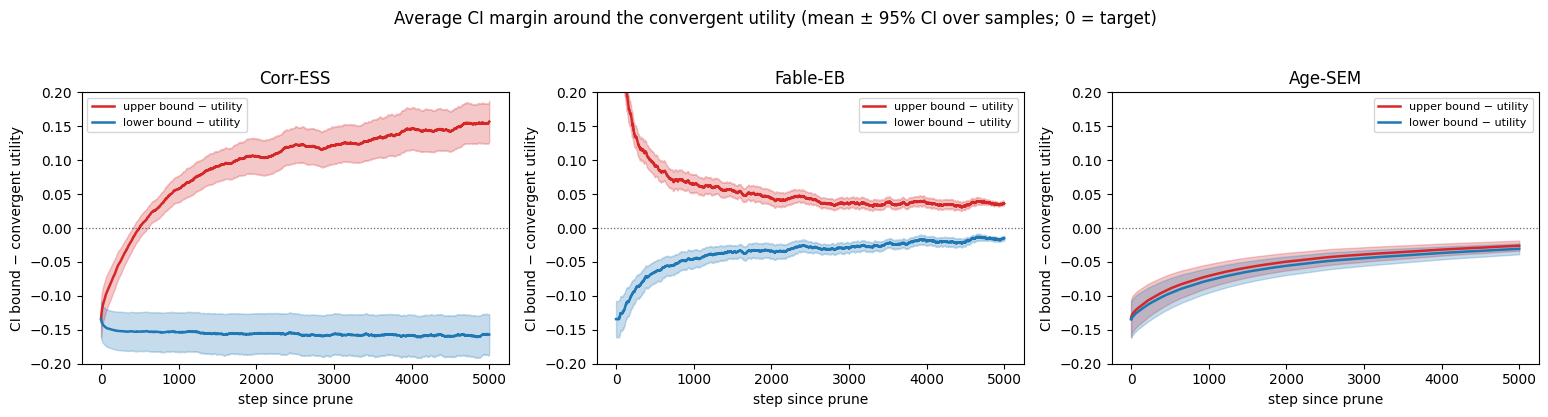

In [61]:
# === Deliverable 1 (miss rates) + Deliverable 2 (average CI margins) ===
# Miss rates: over every (sample, step), how often did the convergent utility fall BELOW the lower
# bound or ABOVE the upper bound? A calibrated 95% CI misses ~2.5% each side, ~5% total. The early
# transient (weight still rising from 0) unavoidably inflates the "above upper" tail, so we also
# report the total miss over the converged 2nd half of the window for reference.
half = TRACK_STEPS // 2
print(f"{'method':<12}{'util < lower':>14}{'util > upper':>14}{'total':>9}    {'2nd-half total':>14}")
for m, (name, _) in enumerate(CI_METHODS):
    lo, hi = lo_all[:, :, m], hi_all[:, :, m]
    tgt = targets[:, None]
    below, above = (tgt < lo).mean(), (tgt > hi).mean()
    below2, above2 = (tgt < lo[:, half:]).mean(), (tgt > hi[:, half:]).mean()
    print(f"{name:<12}{below*100:>13.2f}%{above*100:>13.2f}%{(below + above) * 100:>8.2f}%"
          f"    {(below2 + above2) * 100:>13.2f}%")

# Average CI margins: per step, how far each bound sits from the convergent utility, averaged over
# samples (with its own 95% CI across samples). 0 is the target; the upper bound should sit above it
# and the lower bound below it once the estimate has settled.
fig, axes = plt.subplots(1, len(CI_METHODS), figsize=(5.2 * len(CI_METHODS), 4.0), sharex=True)
axes = np.atleast_1d(axes).ravel()
for ax, (name, _), m in zip(axes, CI_METHODS, range(len(CI_METHODS))):
    for bound, color, label in [(hi_all[:, :, m], 'tab:red', 'upper bound − utility'),
                                (lo_all[:, :, m], 'tab:blue', 'lower bound − utility')]:
        margin = bound - targets[:, None]
        mean = margin.mean(0)
        sem = margin.std(0, ddof=1) / np.sqrt(margin.shape[0])
        ax.plot(steps, mean, color=color, lw=1.8, label=label)
        ax.fill_between(steps, mean - Z * sem, mean + Z * sem, color=color, alpha=0.25)
    ax.axhline(0.0, color='black', lw=0.9, ls=':', alpha=0.6)
    ax.set_title(name)
    ax.set_xlabel('step since prune')
    ax.set_ylabel('CI bound − convergent utility')
    ax.set_ylim(-0.2, 0.2)
    ax.legend(fontsize=8)
fig.suptitle('Average CI margin around the convergent utility '
             '(mean ± 95% CI over samples; 0 = target)', y=1.03)
fig.tight_layout()
plt.show()

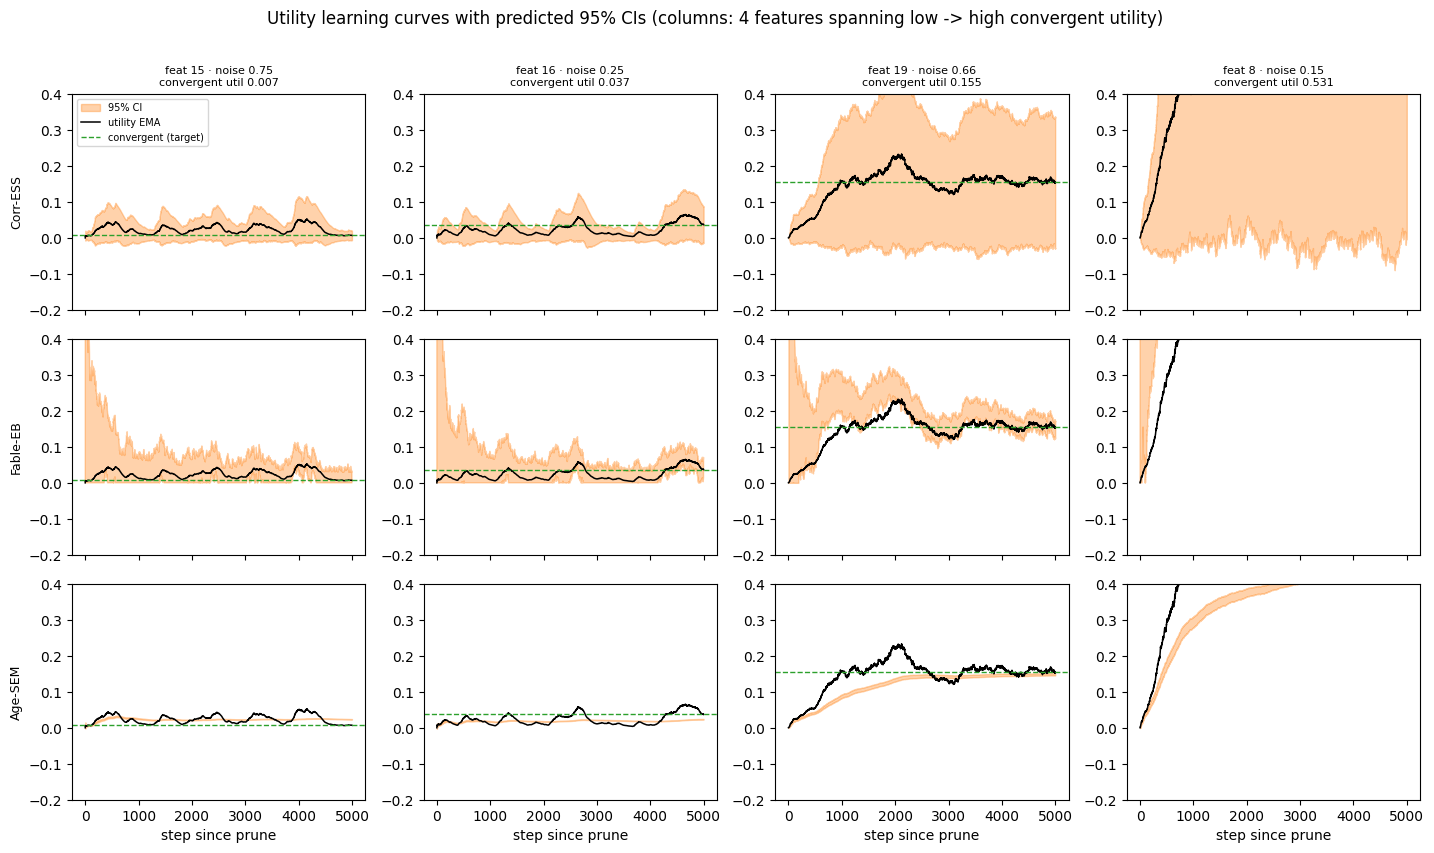

In [62]:
# === Deliverable 3: example utility learning-curves with each method's 95% CI (4 features) ===
# Columns are 4 sampled features spanning the range of convergent utility (low -> high). In each
# panel: black = the ground-truth utility EMA over the window, orange band = the method's 95% CI at
# each step, dashed green = the convergent (end-of-window) target the CI is trying to bracket.
order = np.argsort(targets)
examples = order[np.linspace(0, len(order) - 1, 4).round().astype(int)]   # spread of utilities

fig, axes = plt.subplots(len(CI_METHODS), len(examples),
                         figsize=(3.6 * len(examples), 2.8 * len(CI_METHODS)), sharex=True)
for r, (name, _) in enumerate(CI_METHODS):
    for c, s in enumerate(examples):
        ax = axes[r, c]
        ax.fill_between(steps, lo_all[s, :, r], hi_all[s, :, r],
                        color='tab:orange', alpha=0.35, label='95% CI')
        ax.plot(steps, gt_all[s], color='black', lw=1.1, label='utility EMA')
        ax.axhline(targets[s], color='tab:green', ls='--', lw=1.0, label='convergent (target)')
        if r == 0:
            ax.set_title(f'feat {prune_idxs[s]} · noise {noise_coefs[s]:.2f}\n'
                         f'convergent util {targets[s]:.3f}', fontsize=8)
        if c == 0:
            ax.set_ylabel(name, fontsize=9)
        if r == len(CI_METHODS) - 1:
            ax.set_xlabel('step since prune')
            
        ax.set_ylim(-0.2, 0.4)
axes[0, 0].legend(fontsize=7, loc='upper left')
fig.suptitle('Utility learning curves with predicted 95% CIs '
             '(columns: 4 features spanning low -> high convergent utility)', y=1.01)
fig.tight_layout()
plt.show()

# V3.1: Confidence-Based Pruning

Track how frequently generated features are worthwhile, and how frequently they are not worth the opportunity cost. Use this to determine when a feature should be pruned. To determine if a feature is worthwhile, we need to define a horizon we care about.

I can just start by pruning randomly at a fixed interval, each time making a guess of how likely a prune is to be good, then using privileged information to see if my guess was right. I will say a prune is good if, over a fixed horizon, the prune would have resulted in lower loss.

After I test with a fixed horizon, I can try an infinite horizon.

Step 500 loss: 2.004331975932784
Step 1000 loss: 1.258385595157542
Step 1500 loss: 1.017783230956221
Step 2000 loss: 0.9869699033649391
Step 2500 loss: 0.84758296322655
Step 3000 loss: 0.7026364481704138
Step 3500 loss: 1.095515623459482
Step 4000 loss: 0.9944956637015484
Step 4500 loss: 0.9980294511169961
Step 5000 loss: 1.0419954732264376
Step 5500 loss: 1.344888536994858
Step 6000 loss: 1.2928285313413295
Step 6500 loss: 1.2735759980495818
Step 7000 loss: 1.3066391460693163
Step 7500 loss: 1.2070975014232959
Step 8000 loss: 1.11864479820647
Step 8500 loss: 1.100907918283198
Step 9000 loss: 1.0027742543517648
Step 9500 loss: 1.1759766440562998
Step 10000 loss: 1.1403027777626253


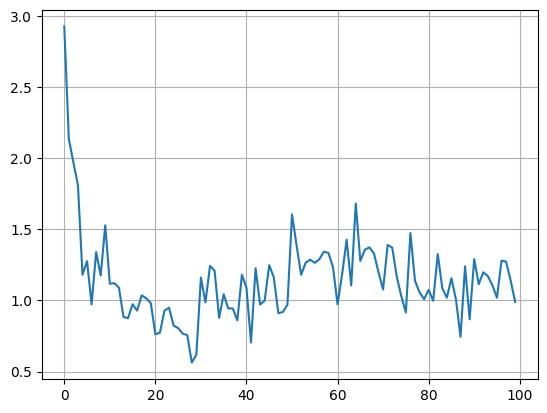

In [32]:
### Task init ###
task = FeatureSiftingTask(n_learner_features=INPUT_DIM, seed=SEED)
x, y = task.step(np.zeros(INPUT_DIM))

### Parameters ###
step_size = 0.01
train_steps = 10000
log_freq = 500
horizon = 1000
prune_freq = horizon

### Network init ###
weight_init_bound = np.sqrt(3/INPUT_DIM)
weights = np.random.uniform(-weight_init_bound, weight_init_bound, size=INPUT_DIM)

### Simulate losses without pruning ###
def simulate_no_prune_loss(task, weights, steps):
    task = deepcopy(task)
    weights = deepcopy(weights)
    losses = []
    for i in range(steps):
        x, y = task.step(np.zeros(INPUT_DIM))
        pred = x @ weights
        error = y - pred
        loss = error ** 2
        losses.append(loss)
        grad = error * -x
        weights -= step_size * grad
    return losses

losses = []
good_prune_guesses = []
good_prune_ground_truths = []
last_no_prune_loss = np.sum(simulate_no_prune_loss(task, weights, horizon))

for i in range(train_steps):
    
    ### Forward pass ###
    pred = x @ weights
    error = y - pred
    loss = error ** 2
    losses.append(loss)
    
    ### Backward pass ###
    grad = error * -x
    weights -= step_size * grad
    
    ### Pruning ###
    prune_mask = np.zeros(INPUT_DIM)
    if (i + 1) % prune_freq == 0:
        # Evaluate previous prune guess
        with_prune_loss = np.sum(losses[-horizon:])
        no_prune_loss = last_no_prune_loss
        was_good_prune = with_prune_loss <= no_prune_loss
        good_prune_ground_truths.append(was_good_prune)
        
        # Prune a new feature
        lowest_idx = np.random.randint(0, INPUT_DIM)
        prune_mask[lowest_idx] = 1
        is_good_prune = np.random.rand() < 0.5
        good_prune_guesses.append(is_good_prune)
        last_no_prune_loss = np.sum(simulate_no_prune_loss(task, weights, horizon))
    
    ### New sample ###
    x, y = task.step(prune_mask)
    
    ### Logging ###
    if (i + 1) % log_freq == 0:
        print(f'Step {i + 1} loss: {np.mean(losses[-log_freq:])}')


plt.plot(np.mean(np.array(losses).reshape(100, -1), axis=1))
plt.grid(True)

# plt.scatter(np.abs(weights), utilities)
# plt.xlabel('Weight Magnitude')
# plt.ylabel('Utility')
# plt.title('Utility vs Weight Magnitude')
# plt.show()


In [33]:
task.noise_coefficients

array([0.81585355, 0.70755172, 0.60166415, 0.2470575 , 0.72965545,
       0.17565562, 0.19096498, 0.24914597, 0.76644188, 0.42268722,
       0.02831967, 0.12428328, 0.67062441, 0.20438984, 0.52884839,
       0.15546202, 0.99720994, 0.98083534, 0.68554198, 0.6091187 ])